#  Import Packages and Functions
We'll make use of the following packages:

* numpy and pandas is what we'll use to manipulate our data
* matplotlib.pyplot and seaborn will be used to produce plots for visualization
* util will provide the locally defined utility functions that have been provided for this assignment
We will also use several modules from the keras framework for building deep learning models.

Run the next cell to import all the necessary packages.



In [1]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import cv2
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization
from sklearn.metrics import matthews_corrcoef, roc_curve, precision_recall_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
base_data_dir = '/Users/Kyle/Desktop/UMD/Fall 2023/CIS 690/data/leukemia'
os.listdir(base_data_dir)

['ABNORMAL.zip',
 '.DS_Store',
 'NORMAL.zip',
 'leukemia-80.10.10',
 'leukemia-80.10.10.zip',
 'ABNORMAL',
 'leukemia-80.10.10 2',
 'NORMAL']

In [3]:
train_dir = "/Users/Kyle/Desktop/UMD/Fall 2023/CIS 690/data/leukemia/leukemia-80.10.10/leukemia_train"
val_dir = "/Users/Kyle/Desktop/UMD/Fall 2023/CIS 690/data/leukemia/leukemia-80.10.10/leukemia_validate"
test_dir = "/Users/Kyle/Desktop/UMD/Fall 2023/CIS 690/data/leukemia/leukemia-80.10.10/leukemia_test"

# 2. Image Preprocessing
Before training, we'll first modify your images to be better suited for training a convolutional neural network. For this task we'll use the Keras ImageDataGenerator function to perform data preprocessing and data augmentation.

This class also provides support for basic data augmentation such as random horizontal flipping of images.
We also use the generator to transform the values in each batch so that their mean is 0 and their standard deviation is 1 (this will faciliate model training by standardizing the input distribution).
The generator also converts our single channel X-ray images (gray-scale) to a three-channel format by repeating the values in the image across all channels (we will want this because the pre-trained model that we'll use requires three-channel inputs).

In [4]:
image_generator = ImageDataGenerator(
    # rotation_range=20,
    # width_shift_range=0.1,
    # shear_range=0.1,
    # zoom_range=0.1,
    # samplewise_center=True,
    # samplewise_std_normalization=True
)

# Build a separate generator fo valid and test sets

Now we need to build a new generator for validation and t esting data.

Why can't use the same generator as for the training data?

Look back at the generator we wrote for the training data.

It normalizes each image per batch, meaning thatit uses batch statistics.
We should not do this with the test and validation data, since in a real life scenario we don't process incoming images a batch at a time (we process one image at a time).
Knowing the average per batch of test data would effectively give our model an advantage (The model should not have any information about the test data).
What we need to do is to normalize incomming test data using the statistics computed from the training set.

In [5]:
train = image_generator.flow_from_directory(train_dir, 
                                            batch_size=8, 
                                            shuffle=True, 
                                            class_mode='binary',
                                            target_size=(144, 144))

validation = image_generator.flow_from_directory(val_dir, 
                                                batch_size=1, 
                                                shuffle=False, 
                                                class_mode='binary',
                                                target_size=(144, 144))

test = image_generator.flow_from_directory(test_dir, 
                                            batch_size=1, 
                                            shuffle=False, 
                                            class_mode='binary',
                                            target_size=(144, 144))

Found 64971 images belonging to 2 classes.
Found 8121 images belonging to 2 classes.
Found 8122 images belonging to 2 classes.


The dimensions of the image are 144 pixels width and 144 pixels height, one single color channel.
The maximum pixel value is 255.0000 and the minimum is 21.0000
The mean value of the pixels is 200.5548 and the standard deviation is 52.1198


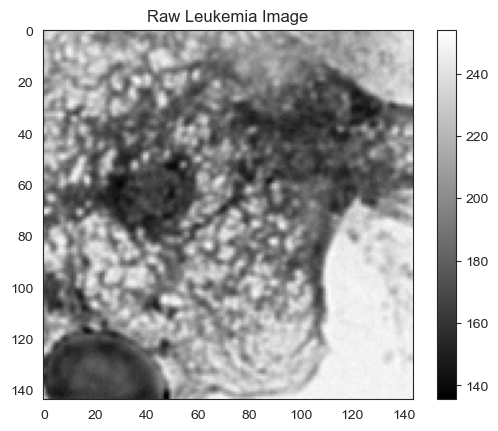

In [6]:
sns.set_style('white')
generated_image, label = train.__getitem__(0)
generated_img_gray = cv2.cvtColor(generated_image[0], cv2.COLOR_BGR2GRAY)
plt.imshow(generated_img_gray, cmap='gray')
plt.colorbar()
plt.title('Raw Leukemia Image')

print(f"The dimensions of the image are {generated_image.shape[1]} pixels width and {generated_image.shape[2]} pixels height, one single color channel.")
print(f"The maximum pixel value is {generated_image.max():.4f} and the minimum is {generated_image.min():.4f}")
print(f"The mean value of the pixels is {generated_image.mean():.4f} and the standard deviation is {generated_image.std():.4f}")

Text(0, 0.5, '# Pixels in Image')

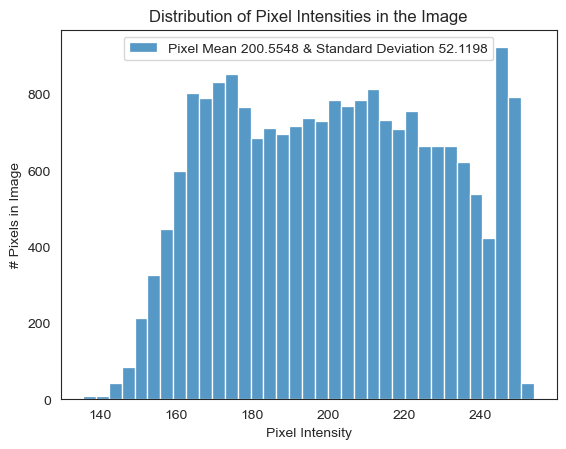

In [7]:
sns.histplot(generated_img_gray.ravel(),
            label=f"Pixel Mean {np.mean(generated_image):.4f} & Standard Deviation {np.std(generated_image):.4f}", kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')

# Building a CNN model

## Impact of imbalance data on loss function

Loss Function:
$$\mathcal{L}_{cross-entropy}(x_i) = -(y_i \log(f(x_i)) + (1-y_i) \log(1-f(x_i))),$$

We can rewrite the the overall average cross-entropy loss over the entire training set `D` of size `N` as follows:
$$\mathcal{L}_{cross-entropy}(\mathcal{D}) = - \frac{1}{N}\big( \sum_{\text{positive examples}} \log (f(x_i)) + \sum_{\text{negative examples}} \log(1-f(x_i)) \big).$$



When we have an imbalance data, using a normal loss function will result a model that bias toward the dominating class. One solution is to use a weighted loss function. Using weighted loss function will balance the contribution in the loss function.

$$\mathcal{L}_{cross-entropy}^{w}(x) = - (w_{p} y \log(f(x)) + w_{n}(1-y) \log( 1 - f(x) ) ).$$

In [8]:
num_normal = len(os.listdir(train_dir + "/NORMAL"))
num_abnormal = len(os.listdir(train_dir + "/ABNORMAL"))

# Class weights
weight_for_0 = num_abnormal / (num_normal + num_abnormal)
weight_for_1 = num_normal / (num_normal + num_abnormal)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for class 0: {weight_for_0:.2f}")
print(f"Weight for class 1: {weight_for_1:.2f}")

Weight for class 0: 0.75
Weight for class 1: 0.25


In [9]:
model_cnn = Sequential()

model_cnn.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(144, 144, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.2))

model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(loss='binary_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])


In [10]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 142, 142, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 142, 142, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 140, 140, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 140, 140, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 70, 70, 32)        0         
 D)                                                              
                                                        

In [11]:
r_cnn = model_cnn.fit(
    train, 
    epochs=10,
    validation_data=validation, 
    class_weight=class_weight,
    steps_per_epoch=100,
    validation_steps=25,
)

Epoch 1/10
100/100 [==============================] - 19s 186ms/step - loss: 1.1401 - accuracy: 0.7513 - val_loss: 1.5581e-12 - val_accuracy: 1.0000
Epoch 2/10
100/100 [==============================] - 19s 193ms/step - loss: 0.2639 - accuracy: 0.7600 - val_loss: 0.0233 - val_accuracy: 1.0000
Epoch 3/10
100/100 [==============================] - 20s 196ms/step - loss: 0.1927 - accuracy: 0.7900 - val_loss: 4.2804e-04 - val_accuracy: 1.0000
Epoch 4/10
100/100 [==============================] - 19s 190ms/step - loss: 0.1808 - accuracy: 0.7437 - val_loss: 0.0296 - val_accuracy: 1.0000
Epoch 5/10
100/100 [==============================] - 20s 195ms/step - loss: 0.1581 - accuracy: 0.7450 - val_loss: 0.0712 - val_accuracy: 1.0000
Epoch 6/10
100/100 [==============================] - 19s 195ms/step - loss: 0.2181 - accuracy: 0.7437 - val_loss: 0.0653 - val_accuracy: 1.0000
Epoch 7/10
100/100 [==============================] - 18s 179ms/step - loss: 0.1829 - accuracy: 0.7538 - val_loss: 1.3295 

Text(0.5, 1.0, 'Accuracy Evolution')

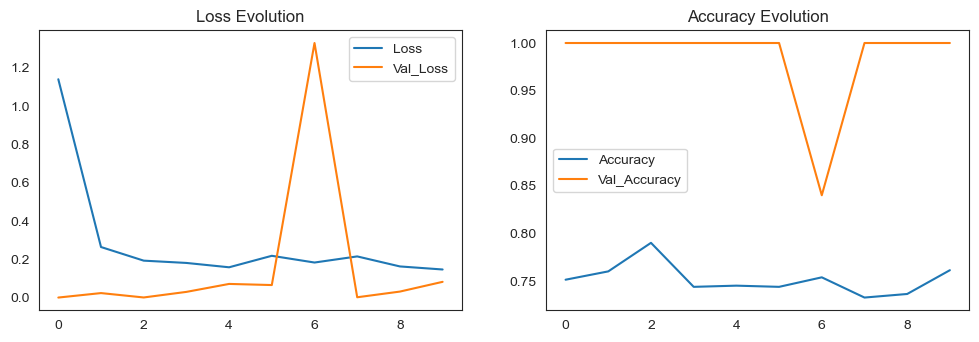

In [12]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r_cnn.history['loss'], label='Loss')
plt.plot(r_cnn.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r_cnn.history['accuracy'], label='Accuracy')
plt.plot(r_cnn.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

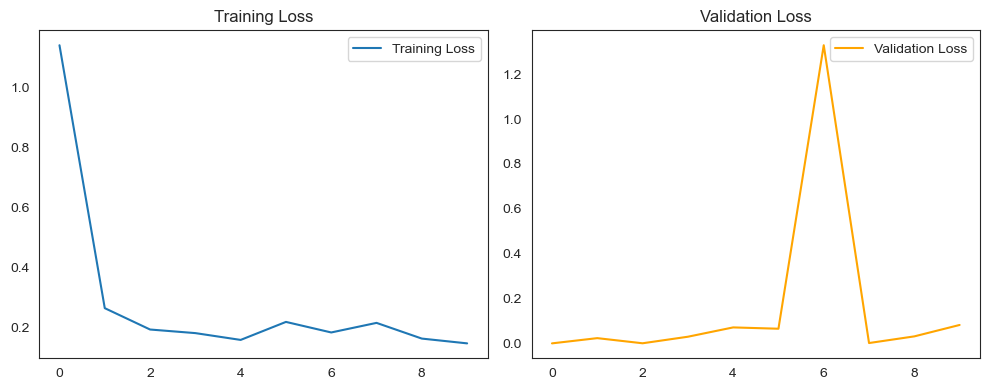

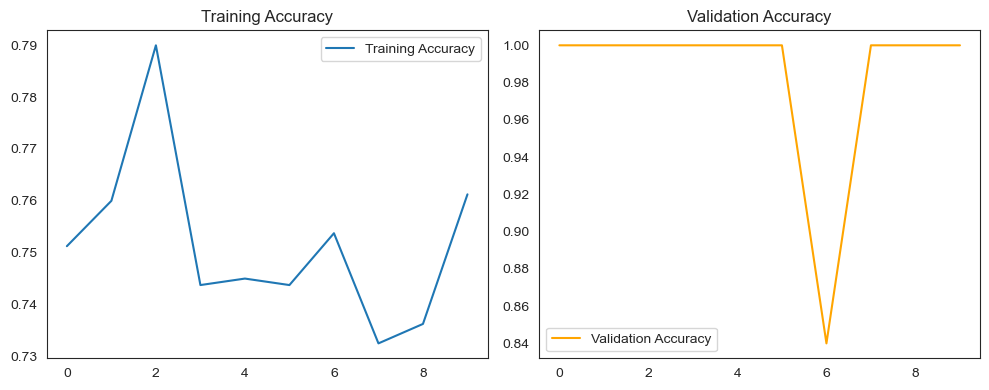

In [13]:
# Plot Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(r_cnn.history['loss'], label='Training Loss')
plt.legend()
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(r_cnn.history['val_loss'], label='Validation Loss', color='orange')
plt.legend()
plt.title('Validation Loss')

plt.tight_layout()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(r_cnn.history['accuracy'], label='Training Accuracy')
plt.legend()
plt.title('Training Accuracy')

plt.subplot(1, 2, 2)
plt.plot(r_cnn.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.legend()
plt.title('Validation Accuracy')

plt.tight_layout()
plt.show()

In [14]:
evaluation = model_cnn.evaluate(test)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = model_cnn.evaluate(train)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

8122/8122 [==============================] - 119s 15ms/step - loss: 0.4190 - accuracy: 0.8361
Test Accuracy: 83.61%
8122/8122 [==============================] - 1118s 138ms/step - loss: 0.4143 - accuracy: 0.8341
Train Accuracy: 83.41%


In [15]:
predictions_cnn = model_cnn.predict(test)

8122/8122 [==============================] - 89s 11ms/step


In [16]:
print(pd.DataFrame(classification_report(test.classes, predictions_cnn > 0.5, output_dict=True)))

                     0            1  accuracy    macro avg  weighted avg
precision     0.829549     0.888889  0.836124     0.859219      0.844387
recall        0.983582     0.393895  0.836124     0.688738      0.836124
f1-score      0.900023     0.545889  0.836124     0.722956      0.811467
support    6091.000000  2031.000000  0.836124  8122.000000   8122.000000


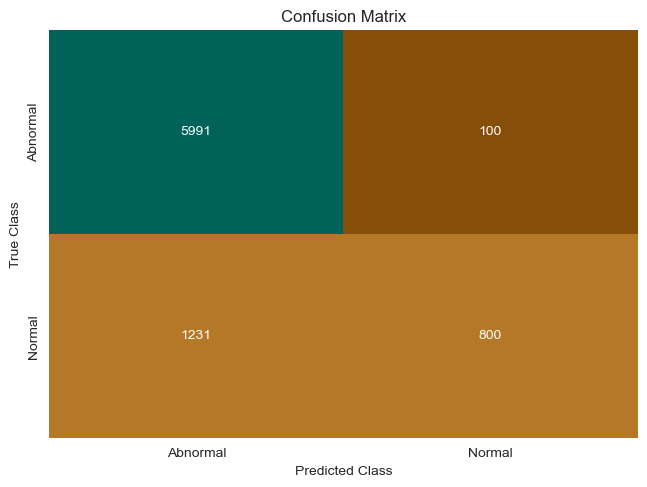

In [17]:
matrix = confusion_matrix(test.classes, predictions_cnn > 0.5)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [18]:
print(pd.DataFrame(classification_report(test.classes, predictions_cnn > 0.7, output_dict=True)))

                     0            1  accuracy    macro avg  weighted avg
precision     0.760115     0.964912  0.762989     0.862514      0.811327
recall        0.999343     0.054161  0.762989     0.526752      0.762989
f1-score      0.863465     0.102564  0.762989     0.483015      0.673193
support    6091.000000  2031.000000  0.762989  8122.000000   8122.000000


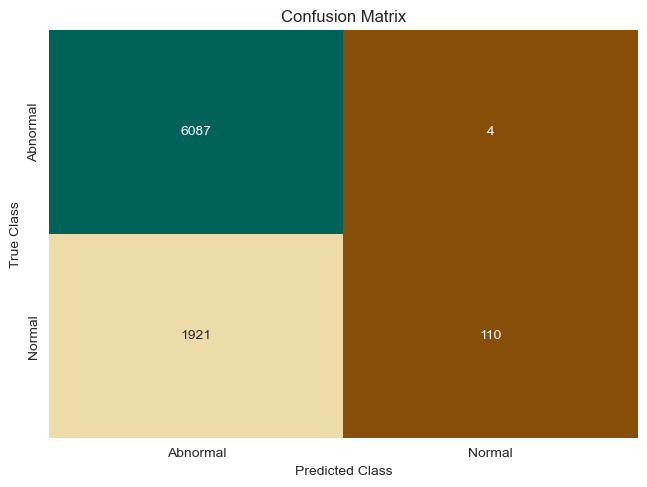

In [19]:
matrix = confusion_matrix(test.classes, predictions_cnn > 0.7)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [20]:
# Calculate Matthews correlation coefficient
mcc = matthews_corrcoef(test.classes, predictions_cnn > 0.5)
print(f"Matthews Correlation Coefficient: {mcc}")

Matthews Correlation Coefficient: 0.5207625230448646


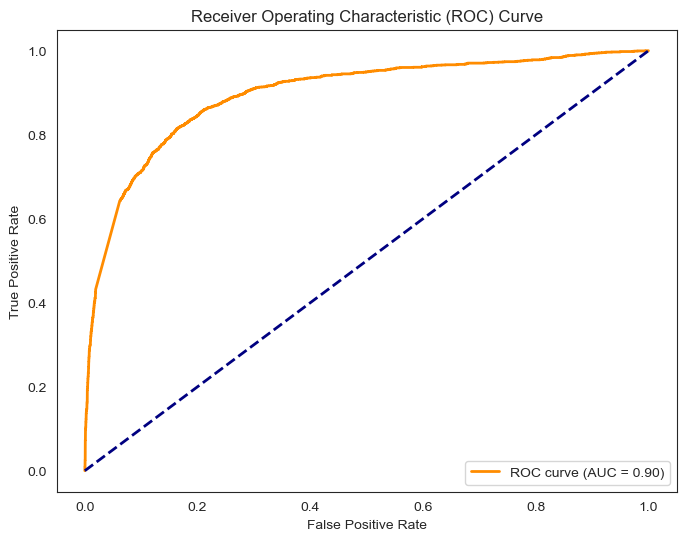

In [21]:
# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(test.classes, predictions_cnn)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

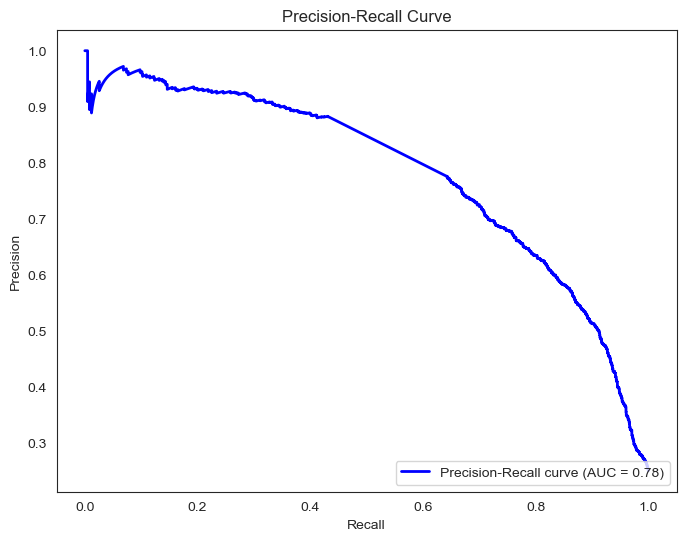

In [22]:
# Calculate precision-recall curve and AUC
precision, recall, _ = precision_recall_curve(test.classes, predictions_cnn)
pr_auc = auc(recall, precision)

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()

In [23]:
model_cnn.save("models/leukemia_cnn_80-10-10_v1.1_03-06-24.h5")

/Users/Kyle/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Transfer Learning
# DenseNet
Densenet is a convolutional network where each layer is connected to all other layers that are deeper in the network:

* The first layer is connected to the 2nd, 3rd, 4th etc.
* The second layer is conected to the 3rd, 4th, 5th etc.

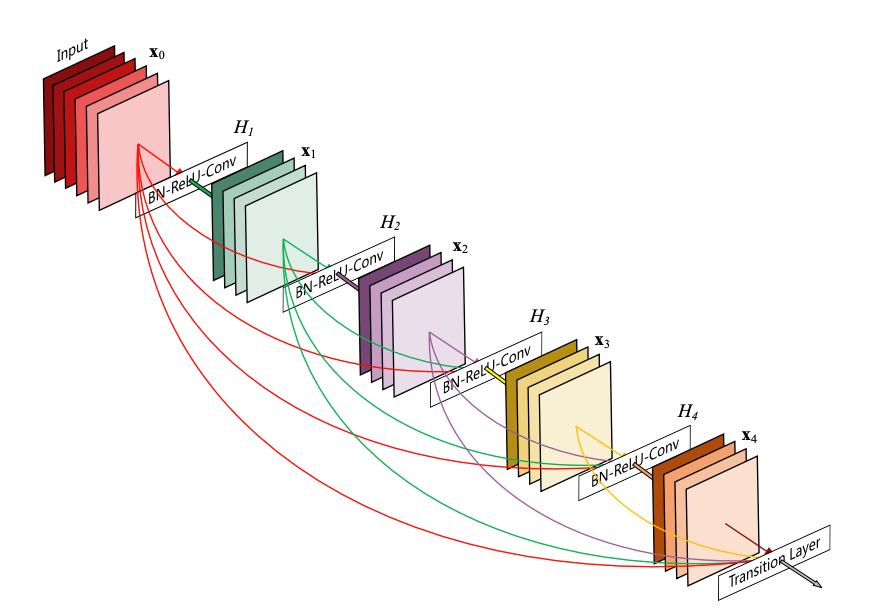

for more information about the DenseNet Architecture visit this website : https://keras.io/api/applications/densenet/


In [24]:
from keras.applications.densenet import DenseNet121
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from keras import backend as K

base_model_densenet = DenseNet121(input_shape=(144, 144, 3), include_top=False, weights='imagenet', pooling='avg')

base_model_densenet.summary()

Model: "densenet121"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 144, 144, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 150, 150, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 72, 72, 64)           9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 72, 72, 64)           256       ['conv1/conv[0][0]']

In [25]:
layers = base_model_densenet.layers
print(f"The model has {len(layers)} layers")

The model has 428 layers


In [26]:
print(f"The input shape {base_model_densenet.input}")
print(f"The output shape {base_model_densenet.output}")

The input shape KerasTensor(type_spec=TensorSpec(shape=(None, 144, 144, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
The output shape KerasTensor(type_spec=TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None), name='avg_pool/Mean:0', description="created by layer 'avg_pool'")


In [27]:
#model = Sequential()
base_model_densenet = DenseNet121(include_top=False, weights='imagenet')
x = base_model_densenet.output

x = GlobalAveragePooling2D()(x)

predictions_densenet = Dense(1, activation="sigmoid")(x)

model_densenet = Model(inputs=base_model_densenet.input, outputs=predictions_densenet)
#model.add(base_model)
#model.add(GlobalAveragePooling2D())
#model.add(Dense(1, activation='sigmoid'))

model_densenet.compile(loss='binary_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

In [28]:
r_densenet = model_densenet.fit(
    train, 
    epochs=10,
    validation_data=validation,
    class_weight=class_weight,
    steps_per_epoch=100,
    validation_steps=25,
)

Epoch 1/10
100/100 [==============================] - 54s 492ms/step - loss: 0.1944 - accuracy: 0.7812 - val_loss: 0.0360 - val_accuracy: 1.0000
Epoch 2/10
100/100 [==============================] - 51s 510ms/step - loss: 0.1519 - accuracy: 0.8050 - val_loss: 0.8774 - val_accuracy: 0.8400
Epoch 3/10
100/100 [==============================] - 52s 518ms/step - loss: 0.1314 - accuracy: 0.8250 - val_loss: 7.0943e-05 - val_accuracy: 1.0000
Epoch 4/10
100/100 [==============================] - 49s 492ms/step - loss: 0.1376 - accuracy: 0.8225 - val_loss: 3.2904e-09 - val_accuracy: 1.0000
Epoch 5/10
100/100 [==============================] - 48s 483ms/step - loss: 0.1432 - accuracy: 0.8138 - val_loss: 0.0074 - val_accuracy: 1.0000
Epoch 6/10
100/100 [==============================] - 49s 490ms/step - loss: 0.1279 - accuracy: 0.8500 - val_loss: 0.1952 - val_accuracy: 0.9600
Epoch 7/10
100/100 [==============================] - 46s 458ms/step - loss: 0.1397 - accuracy: 0.8288 - val_loss: 0.0742 

Text(0.5, 1.0, 'Accuracy Evolution')

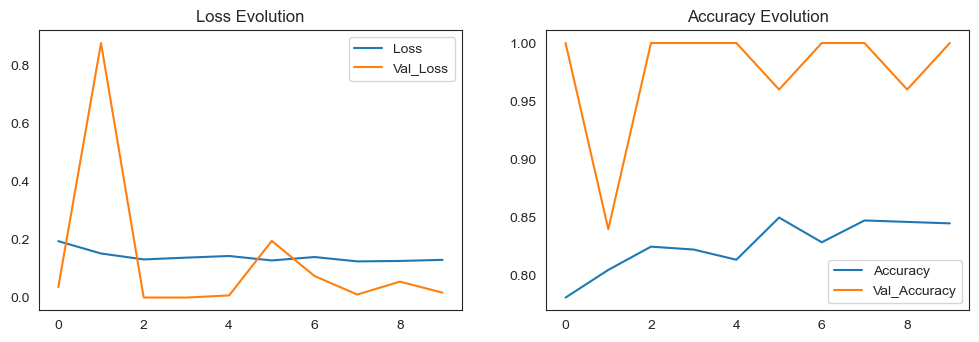

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r_densenet.history['loss'], label='Loss')
plt.plot(r_densenet.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r_densenet.history['accuracy'], label='Accuracy')
plt.plot(r_densenet.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [30]:
evaluation = model_densenet.evaluate(test)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = model_densenet.evaluate(train)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

8122/8122 [==============================] - 246s 30ms/step - loss: 0.5904 - accuracy: 0.7785
Test Accuracy: 77.85%
8122/8122 [==============================] - 1255s 155ms/step - loss: 0.5872 - accuracy: 0.7793
Train Accuracy: 77.93%


# Evaluation

In [31]:
predictions_densenet = model_densenet.predict(test, steps=len(test))

8122/8122 [==============================] - 255s 31ms/step


In [32]:
print(pd.DataFrame(classification_report(test.classes, predictions_densenet > 0.5, output_dict=True)))

                     0            1  accuracy    macro avg  weighted avg
precision     0.774846     0.869427  0.778503     0.822137      0.798497
recall        0.993269     0.134417  0.778503     0.563843      0.778503
f1-score      0.870566     0.232836  0.778503     0.551701      0.711094
support    6091.000000  2031.000000  0.778503  8122.000000   8122.000000


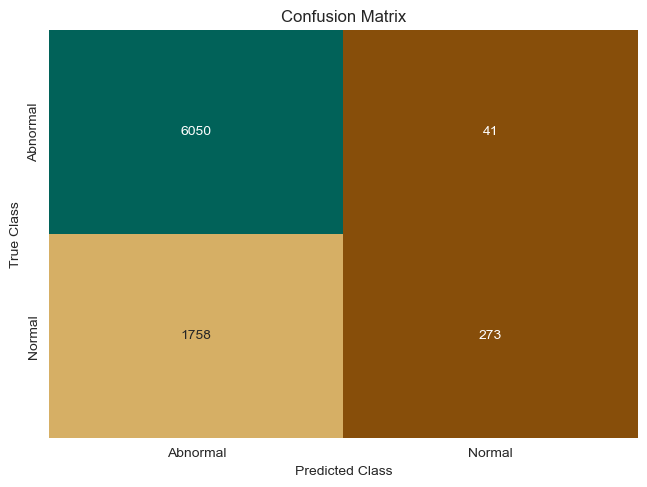

In [33]:
matrix = confusion_matrix(test.classes, predictions_densenet > 0.5)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [34]:
# Calculate Matthews correlation coefficient
mcc = matthews_corrcoef(test.classes, predictions_densenet > 0.5)
print(f"Matthews Correlation Coefficient: {mcc}")

Matthews Correlation Coefficient: 0.28681736319067075


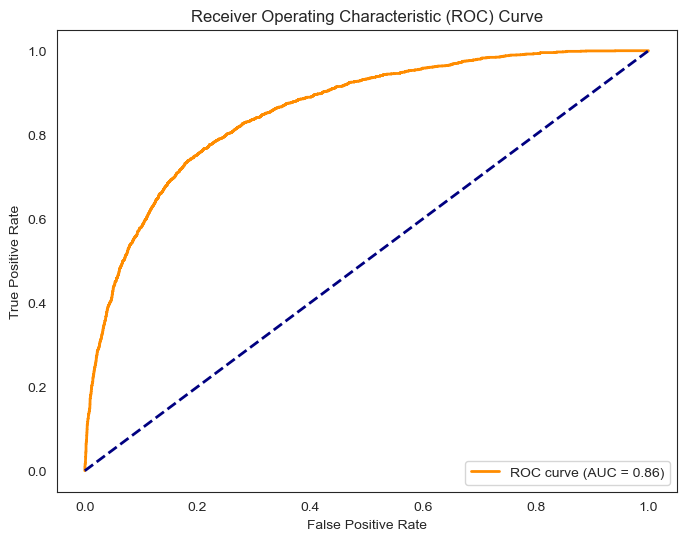

In [35]:
# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(test.classes, predictions_densenet)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

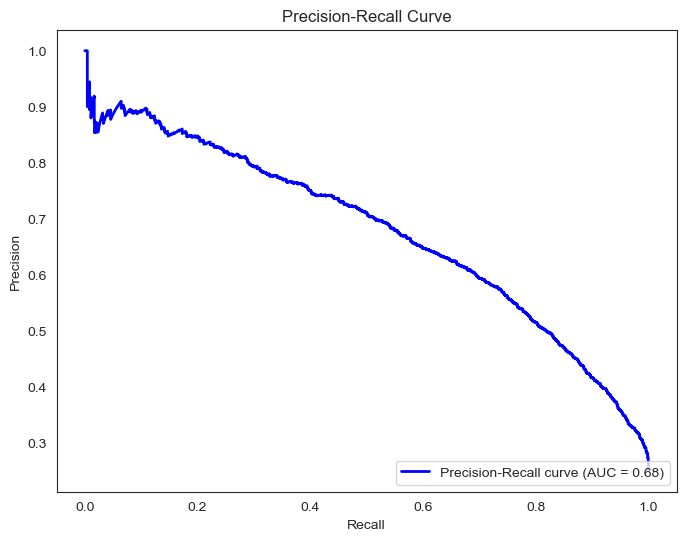

In [36]:
# Calculate precision-recall curve and AUC
precision, recall, _ = precision_recall_curve(test.classes, predictions_densenet)
pr_auc = auc(recall, precision)

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()

In [38]:
model_densenet.save("models/leukemia_densenet_80-10-10_v1.1_03-06-24.h5")

# VGG16
Presented in 2014, VGG16 has a very simple and classical architecture, with blocks of 2 or 3 convolutional layers followed by a pooling layer, plus a final dense network composed of 2 hidden layers (of 4096 nodes each) and one output layer (of 1000 nodes). Only 3x3 filters are used.

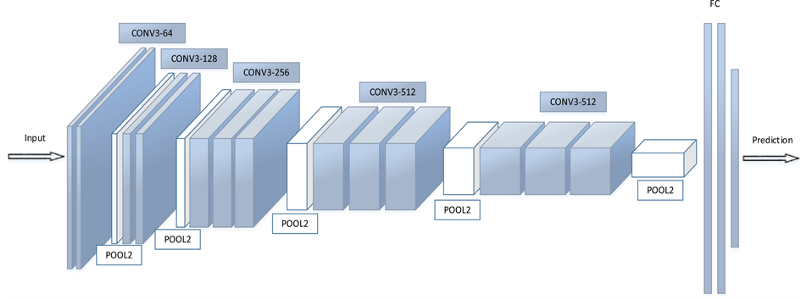

In [ ]:
from keras.models import Sequential
from keras.layers import GlobalAveragePooling2D
from keras.applications import VGG16

vgg16_base_model = VGG16(input_shape=(180,180,3),include_top=False,weights='imagenet')

In [ ]:
vgg16_base_model.summary()

In [ ]:
vgg16_model = Sequential([
    vgg16_base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.6),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64,activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])
    
model = Sequential()
model.add(vgg16_model.layers[0])

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

vgg16_model.compile(optimizer=opt,loss='binary_crossentropy',metrics=METRICS)

In [ ]:
r = vgg16_model.fit(train,
          epochs=10,
          validation_data=validation,
          class_weight=class_weight,
          steps_per_epoch=100,
          validation_steps=25)

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [ ]:
# evaluation =vgg16_model.evaluate(test)
# print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = vgg16_model.evaluate(train)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

In [ ]:
predicted_vals = vgg16_model.predict(test, steps=len(test))

In [ ]:
print(pd.DataFrame(classification_report(test.classes, predicted_vals > 0.5, output_dict=True)))

matrix = confusion_matrix(test.classes, predicted_vals > 0.5)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# ResNet

See the full explanation and schemes in the Research Paper on Deep Residual Learning (https://arxiv.org/pdf/1512.03385.pdf)

In [ ]:
from keras.applications import ResNet50

resnet_base_model = ResNet50(input_shape=(180,180,3), include_top=False, weights='imagenet')

In [ ]:
resnet_base_model.summary()

In [ ]:
resnet_model = Sequential([
    resnet_base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.6),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64,activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
resnet_model.compile(optimizer=opt,loss='binary_crossentropy',metrics=METRICS)

In [ ]:
r = resnet_model.fit(
    train,
    epochs=10,
    validation_data=validation,
    class_weight=class_weight,
    steps_per_epoch=100,
    validation_steps=25
)


In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [ ]:
# evaluation = resnet_model.evaluate(test)
# print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = resnet_model.evaluate(train)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

In [ ]:
predicted_vals = resnet_model.predict(test, steps=len(test))

In [ ]:
print(pd.DataFrame(classification_report(test.classes, predicted_vals > 0.5, output_dict=True)))

matrix = confusion_matrix(test.classes, predicted_vals > 0.5)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# InceptionNet
Also known as GoogleNet, this architecture presents sub-networks called inception modules, which allows fast training computing, complex patterns detection, and optimal use of parameters

for more information visit https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43022.pdf



In [ ]:
from keras.applications import InceptionV3

inception_base_model = InceptionV3(input_shape=(180,180,3),include_top=False,weights='imagenet')

In [ ]:
inception_model = Sequential([
    inception_base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.6),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64,activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
inception_model.compile(optimizer=opt,loss='binary_crossentropy',metrics=METRICS)

In [ ]:
r = inception_model.fit(
    train,
    epochs=10,
    validation_data=validation,
    class_weight=class_weight,
    steps_per_epoch=100,
    validation_steps=25
)

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [ ]:
# evaluation = inception_model.evaluate(test)
# print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")

evaluation = inception_model.evaluate(train)
print(f"Train Accuracy: {evaluation[1] * 100:.2f}%")

In [ ]:
predicted_vals = inception_model.predict(test, steps=len(test))

In [ ]:
print(pd.DataFrame(classification_report(test.classes, predicted_vals > 0.5, output_dict=True)))

matrix = confusion_matrix(test.classes, predicted_vals > 0.5)
df_confusion = pd.DataFrame(matrix, index=['Abnormal','Normal'],columns=['Abnormal','Normal'])

# create and display confusion matrix heatmap
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(df_confusion, annot=True, fmt='d', cbar=None, cmap=colormap)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [ ]:
# # manual predictions
# from keras.preprocessing import image
# from keras.applications.inception_v3 import preprocess_input, decode_predictions

# # Load the image using OpenCV
# image_path = 'data/random_predictions/1-4621.jpeg'
# img = cv2.imread(image_path)
# img = cv2.resize(img, (180, 180))  # Resize the image to match InceptionV3 input size

# # Preprocess the image
# img = image.img_to_array(img)
# img = np.expand_dims(img, axis=0)
# img = preprocess_input(img)

# # Make predictions
# predictions = inception_model.predict(img)

# # Decode predictions 
# #decoded_predictions = decode_predictions(predictions)

# # Print the top prediction
# predicted_class = np.argmax(predictions)
# print(f'Predicted class index: {predicted_class}')

# # Print the entire prediction array
# print('Prediction array:', predictions)


In [ ]:
def binary_convert(x, threshold=0.5):
    return np.where(x > threshold, 1, 0)

In [ ]:
img_size = 180
def manual_prediction(image_path):
    img_test = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_test = cv2.resize(img_test, (img_size, img_size))
    img_test = np.expand_dims(img_test, axis=0)
    img_test = np.expand_dims(img_test, axis=-1)

    img_test = np.array(img_test) / 255

    #print("Input shape:", img_test.shape)
    #print("Input:", img_test[:5][0])
    
    manual_predictions = model.predict(img_test)
    manual_predicted_class = binary_convert(manual_predictions)

    print("Raw predictions:", manual_predictions)
    print("Predicted class:", manual_predicted_class)

    #img_test = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    #plt.imshow(img_test, cmap='gray')
    #plt.show()  


In [ ]:
manual_prediction("data/random_predictions/0-1445.jpeg")
manual_prediction("data/random_predictions/0-1453.jpeg")
manual_prediction("data/random_predictions/0-1454.jpeg")
manual_prediction("data/random_predictions/0-1473.jpeg")
manual_prediction("data/random_predictions/0-1483.jpeg")
manual_prediction("data/random_predictions/0-1488.jpeg")

In [ ]:
manual_prediction("data/random_predictions/1-4621.jpeg")
manual_prediction("data/random_predictions/1-4623.jpeg")
manual_prediction("data/random_predictions/1-4627.jpeg")
manual_prediction("data/random_predictions/1-4634.jpeg")
manual_prediction("data/random_predictions/1-4641.jpeg")
manual_prediction("data/random_predictions/1-4669.jpeg")


## Comparing different models

In [ ]:
model_mae_scores_dict = {'CNN': 98.26, 'DenseNet' : 99.91, 'VGG16' : 98.27, 'ResNet' : 98.08, 'InceptionNet' : 98.45}

In [ ]:
model_mae_scores = pd.Series(model_mae_scores_dict)
model_mae_scores

order = model_mae_scores.sort_values(ascending=False)
order

In [ ]:
from matplotlib import pyplot
import seaborn as sns

sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.barplot(x=order.values, y = order.index, orient='h')

plt.xlabel('Mean Absolute Error')
plt.xticks(rotation='vertical',fontsize=14)
plt.title('Mean Average Error of All Models Tested')